<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/marco-canas/didactica_ciencia_datos/blob/main/propu/unidad_didac/taller_redes_neuronales/reconocimiento_imagenes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
</table>

## Agenda  

1. Presentación del equipo investigador
2. Motivación Google Lens
3. GitHub y vínculo open in colab 
4. Regresión con una configuración de perceptrones o red neuronal
5. Clasificación con una red neuronal MLP

# Nuestro equipo investigador  

# Nuestros Jóvenes Investigadores

<img src = 'https://github.com/marco-canas/didactica_ciencia_datos/blob/main/propu/unidad_didac/taller_redes_neuronales/dani_edwin_estefa.jpeg?raw=true'>

El coloquio en didáctica de la matemática

Yuber Hernany Tapias Arboleda

## Nuestra fundamentadora bibliográfica y nuestra estudiante de doctorado en finanzas

<img src = 'https://github.com/marco-canas/didactica_ciencia_datos/blob/main/propu/unidad_didac/taller_redes_neuronales/leidy_mariela.jpeg?raw=true'>

# Nuestra coordinadora de investigación  

<img src = ''>

# Aurélien Géron

<img src = 'https://pbs.twimg.com/media/EFjj3p4VAAAxWOj.jpg:large'>

# [Cuederno de GitHub de Geron para el capítulo 10 sobre introducción a las redes neuronales](https://github.com/ageron/handson-ml3/blob/main/10_neural_nets_with_keras.ipynb)


revisar su versión de python

In [ ]:
import sys   # modulo sys 

if sys.version_info >= (3, 7):
    print("La versión instalada de python es mayor a 3.7")

It also requires Scikit-Learn ≥ 1.0.1:

In [ ]:
from packaging import version
import sklearn

if version.parse(sklearn.__version__) >= version.parse("1.0.1"):
    print("la versión de sklearn es mayor o igual a 1.0.1")

Revisar la versión de TensorFlow ≥ 2.8:

In [ ]:
import tensorflow as tf

if version.parse(tf.__version__) >= version.parse("2.8.0"):
    print("La versión de tensorflow es mayor o igual a 2.8.0")

Como hicimos en capítulos anteriores, definamos los tamaños de fuente predeterminados para hacer las figuras más bonitas:

In [ ]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

Y creemos la carpeta images/ann (si aún no existe), y definamos la función `save_fig()` que se usa a través de este cuaderno para guardar las figuras en alta resolución para el libro:

In [12]:
from pathlib import Path  # módulo pathlib 

IMAGES_PATH = Path() / "images" / "ann"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

# From Biological to Artificial Neurons
## The Perceptron with [iris's](https://es.wikipedia.org/wiki/Conjunto_de_datos_flor_iris) dataset



<img src = 'https://upload.wikimedia.org/wikipedia/commons/thumb/b/b0/Perceptr%C3%B3n_5_unidades.svg/400px-Perceptr%C3%B3n_5_unidades.svg.png'>


Construyamos un detector de setosa

<img src = 'https://s3.amazonaws.com/assets.datacamp.com/blog_assets/Machine+Learning+R/iris-machinelearning.png'>

<img src = 'https://live.staticflickr.com/7872/40110698543_23f5e6c0ef_m.jpg'>

[dele aquí para ver en wiki sobre el dataset de iris](https://es.wikipedia.org/wiki/Conjunto_de_datos_flor_iris)

# ¿Cómo aprendimos a reconocer árboles?

<img src = 'https://arbolesfrutales.org/wp-content/uploads/2022/03/TIPOS-DE-ARBOLES-1024x688.jpg'>

`X` es el arbol y `y` es la etiqueta

<img src = 'https://i.ytimg.com/vi/z8RVC7VmY8k/maxresdefault.jpg'>

# Construcción de un detector de setosa

In [16]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.linear_model import Perceptron
# https://es.wikipedia.org/wiki/Conjunto_de_datos_flor_iris
iris = load_iris(as_frame=True)
X = iris.data[["petal length (cm)", "petal width (cm)"]].values
y = (iris.target == 0)  # Iris setosa

per_clf = Perceptron(random_state=42)
per_clf.fit(X, y)


Perceptron(random_state=42)

In [20]:

X_new = [[1.5, 0.2]] 
y_pred = per_clf.predict(X_new)  # predicts True and False for these 2 flowers

if y_pred: 
    print("Es setosa")
else:
    print("no es setosa")    



Es setosa


In [ ]:
# extra code – plots the decision boundary of a Perceptron on the iris dataset

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

a = -per_clf.coef_[0, 0] / per_clf.coef_[0, 1]
b = -per_clf.intercept_ / per_clf.coef_[0, 1]
axes = [0, 5, 0, 2]
x0, x1 = np.meshgrid(
    np.linspace(axes[0], axes[1], 500).reshape(-1, 1),
    np.linspace(axes[2], axes[3], 200).reshape(-1, 1),
)
X_new = np.c_[x0.ravel(), x1.ravel()]
y_predict = per_clf.predict(X_new)
zz = y_predict.reshape(x0.shape)
custom_cmap = ListedColormap(['#9898ff', '#fafab0'])

plt.figure(figsize=(7, 3))
plt.plot(X[y == 0, 0], X[y == 0, 1], "bs", label="Not Iris setosa")
plt.plot(X[y == 1, 0], X[y == 1, 1], "yo", label="Iris setosa")
plt.plot([axes[0], axes[1]], [a * axes[0] + b, a * axes[1] + b], "k-",
         linewidth=3)
plt.contourf(x0, x1, zz, cmap=custom_cmap)
plt.xlabel("Petal length")
plt.ylabel("Petal width")
plt.legend(loc="lower right")
plt.axis(axes)
save_fig('detector_setosa')
plt.show()



In [ ]:
from scipy.special import expit as sigmoid

def relu(z):
    return np.maximum(0, z)

def derivative(f, z, eps=0.000001):
    return (f(z + eps) - f(z - eps))/(2 * eps)

max_z = 4.5
z = np.linspace(-max_z, max_z, 200)

plt.figure(figsize=(11, 3.1))

plt.subplot(121)
plt.plot([-max_z, 0], [0, 0], "r-", linewidth=2, label="Heaviside")
plt.plot(z, relu(z), "m-.", linewidth=2, label="ReLU")
plt.plot([0, 0], [0, 1], "r-", linewidth=0.5)
plt.plot([0, max_z], [1, 1], "r-", linewidth=2)
plt.plot(z, sigmoid(z), "g--", linewidth=2, label="Sigmoid")
plt.plot(z, np.tanh(z), "b-", linewidth=1, label="Tanh")
plt.grid(True)
plt.title("Activation functions")
plt.axis([-max_z, max_z, -1.65, 2.4])
plt.gca().set_yticks([-1, 0, 1, 2])
plt.legend(loc="lower right", fontsize=13)

plt.subplot(122)
plt.plot(z, derivative(np.sign, z), "r-", linewidth=2, label="Heaviside")
plt.plot(0, 0, "ro", markersize=5)
plt.plot(0, 0, "rx", markersize=10)
plt.plot(z, derivative(sigmoid, z), "g--", linewidth=2, label="Sigmoid")
plt.plot(z, derivative(np.tanh, z), "b-", linewidth=1, label="Tanh")
plt.plot([-max_z, 0], [0, 0], "m-.", linewidth=2)
plt.plot([0, max_z], [1, 1], "m-.", linewidth=2)
plt.plot([0, 0], [0, 1], "m-.", linewidth=1.2)
plt.plot(0, 1, "mo", markersize=5)
plt.plot(0, 1, "mx", markersize=10)
plt.grid(True)
plt.title("Derivatives")
plt.axis([-max_z, max_z, -0.2, 1.2])

save_fig("activation_functions_plot")
plt.show()

# Construcción de un regresor para predecir precios de vivienda

In [ ]:
from sklearn.datasets import fetch_california_housing # obtención de datos 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error

from sklearn.pipeline import make_pipeline


housing = fetch_california_housing()
X_train_full, X_test, y_train_full, y_test = train_test_split(
    housing.data, housing.target, random_state=42)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full, y_train_full, random_state=42)

mlp_reg = MLPRegressor(hidden_layer_sizes=[50, 50, 50], random_state=42)
pipeline = make_pipeline(StandardScaler(), mlp_reg)
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_valid)
rmse = mean_squared_error(y_valid, y_pred, squared=False)

In [ ]:
rmse

# RMSE

$$ RMSE = \sqrt{\frac{1}{m}\sum (\hat{y} - y)^{2}} $$

In [ ]:
# extra code – this was left as an exercise for the reader

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier

iris = load_iris()
X_train_full, X_test, y_train_full, y_test = train_test_split(
    iris.data, iris.target, test_size=0.1, random_state=42)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full, y_train_full, test_size=0.1, random_state=42)

mlp_clf = MLPClassifier(hidden_layer_sizes=[5], max_iter=10_000,
                        random_state=42)
pipeline = make_pipeline(StandardScaler(), mlp_clf)
pipeline.fit(X_train, y_train)


# [Dataset de flores de iris Ficher](https://es.wikipedia.org/wiki/Conjunto_de_datos_flor_iris)

In [ ]:
pipeline.predict([[5.1, 3.5, 1.4, 0.2]]) 

In [ ]:
pipeline.predict([[5.0, 2.0, 3.5, 1.0]]) 

In [ ]:
pipeline.predict([[5.9, 3.0, 5.1, 1.8]]) 

In [ ]:
accuracy = pipeline.score(X_valid, y_valid)
accuracy


# Implementing MLPs with Keras  
## Building an Image Classifier Using the Sequential API Using Keras to load the dataset

Comencemos cargando el conjunto de datos MNIST de moda. 

Keras tiene una serie de funciones para cargar conjuntos de datos populares en tf.keras.datasets. El conjunto de datos ya está dividido entre un conjunto de entrenamiento (60 000 imágenes) y un conjunto de prueba (10 000 imágenes), pero puede ser útil dividir aún más el conjunto de entrenamiento para tener un conjunto de validación. Usaremos 55.000 imágenes para entrenamiento y 5.000 para validación.

<img src = 'https://www.bbva.com/wp-content/uploads/2019/03/vision_artificial_01_ESP-1024x485.png'>

In [1]:
import tensorflow as tf

fashion_mnist = tf.keras.datasets.fashion_mnist.load_data()
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist
X_train, y_train = X_train_full[:-5000], y_train_full[:-5000]
X_valid, y_valid = X_train_full[-5000:], y_train_full[-5000:]

El conjunto de entrenamiento contiene 60.000 imágenes en escala de grises, cada una de 28x28 píxeles:

In [2]:
X_train.shape

(55000, 28, 28)

Each pixel intensity is represented as a byte (0 to 255):

In [3]:
X_train.dtype

dtype('uint8')

reduzcamos la intensidad de los píxeles al rango de 0-1 y convirtámoslos en flotantes, dividiéndolos por 255:

In [4]:
X_train, X_valid, X_test = X_train / 255., X_valid / 255., X_test / 255.

Puede trazar una imagen usando la función `imshow()` de Matplotlib, con un mapa de color 'binario':

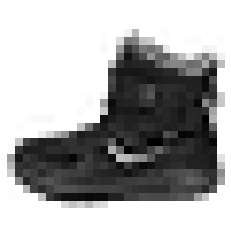

In [7]:
# extra code
import matplotlib.pyplot as plt 
plt.imshow(X_train[0], cmap="binary")
plt.axis('off')
plt.show()

The labels are the class IDs (represented as uint8), from 0 to 9:

In [10]:
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]



So the first image in the training set is an ankle boot:


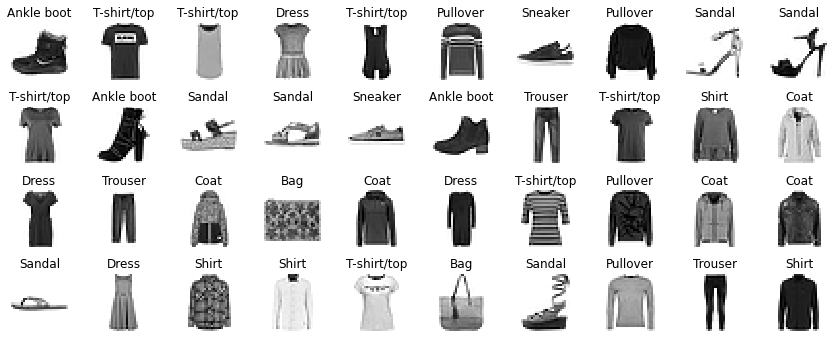

In [13]:
n_rows = 4
n_cols = 10
plt.figure(figsize=(n_cols * 1.2, n_rows * 1.2))
for row in range(n_rows):
    for col in range(n_cols):
        index = n_cols * row + col
        plt.subplot(n_rows, n_cols, index + 1)
        plt.imshow(X_train[index], cmap="binary", interpolation="nearest")
        plt.axis('off')
        plt.title(class_names[y_train[index]])
plt.subplots_adjust(wspace=0.2, hspace=0.5)

save_fig("fashion_mnist_plot")
plt.show()

# Creating the model using the Sequential API  



¡Ahora construyamos la red neuronal! Aquí hay una clasificación MLP con dos capas ocultas:

In [ ]:
tf.random.set_seed(42)
model = tf.keras.Sequential()
model.add(tf.keras.layers.InputLayer(input_shape=[28, 28]))
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(300, activation="relu"))
model.add(tf.keras.layers.Dense(100, activation="relu"))
model.add(tf.keras.layers.Dense(10, activation="softmax"))

Repasemos este código línea por línea:


* The first line creates a Sequential model. This is the simplest kind of Keras model for neural networks that are just composed of a single stack of layers connected sequentially. This is called the Sequential API.


* Next, we build the first layer and add it to the model. It is a
Flatten layer whose role is to convert each input image into a 1D
array: if it receives input data X, it computes X.reshape(-1, 1).
This layer does not have any parameters; it is just there to do some
simple preprocessing. Since it is the first layer in the model, you
should specify the input_shape, which doesn’t include the batch
size, only the shape of the instances. Alternatively, you could add keras.layers.InputLayer as the first layer, setting
input_shape=[28,28].
Next we add a Dense hidden layer with 300 neurons. It will use the
ReLU activation function. Each Dense layer manages its own
weight matrix, containing all the connection weights between the
neurons and their inputs. It also manages a vector of bias terms
(one per neuron). When it receives some input data, it computes
Equation 10-2.
Then we add a second Dense hidden layer with 100 neurons, also
using the ReLU activation function.
Finally, we add a Dense output layer with 10 neurons (one per
class), using the softmax activation function (because the classes
are exclusive).


# Sugerencia 


Specifying activation="relu" is equivalent to specifying
activation=keras.activations.relu. Other activation functions are available in the
keras.activations package, we will use many of them in this book. See
https://keras.io/activations/ for the full list.
Instead of adding the layers one by one as we just did, you can pass a list of
layers when creating the Sequential model

In [15]:
# extra code – clear the session to reset the name counters
tf.keras.backend.clear_session()
tf.random.set_seed(42)

model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=[28, 28]),
    tf.keras.layers.Dense(300, activation="relu"),
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])